# Asimetrías Materia-Antimateria Cota 01

In [12]:
%matplotlib inline
from pathlib import Path
import warnings

import numpy as np
import os
import uproot
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from scipy.optimize import curve_fit as cf

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "Data"

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor' : '#0a0a2e',
    'axes.grid'      : True,
    'grid.color'     : 'white',
    'grid.linestyle' : '--',
    'grid.alpha'     : 0.4,
})

print(f"Directorio del proyecto: {BASE_DIR}")
print(f"Directorio de los datos: {DATA_DIR}")

Directorio del proyecto: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2
Directorio de los datos: c:\Users\mario\Documents\LHCb\Hackaton_2024\opendata-project-1.2\Data


In [2]:
# Preselección de datos 01
PRESELECTION = "(H1_isMuon==0) & (H2_isMuon==0) & (H3_isMuon==0) & (H1_ProbPi<0.5) & (H2_ProbPi<0.5) & (H3_ProbPi<0.5) & (H1_ProbK>0.5) & (H2_ProbK>0.5)  & (H3_ProbK>0.5)"

In [8]:
# Lectura de datos reales
def load_tree(path: Path, cut: str | None = None) -> pd.DataFrame:
    with uproot.open(path) as f:
        tree = f["DecayTree"]
        return tree.arrays(tree.keys(), cut=cut, library="pd")
    
df_up = load_tree(DATA_DIR / "B2HHH_MagnetUp.root", cut = PRESELECTION)
df_down = load_tree(DATA_DIR / "B2HHH_MagnetDown.root", cut = PRESELECTION)
rd = pd.concat([df_up, df_down], ignore_index=True)
print(f"Magnet Up: {len(df_up):,}; Magnet Down: {len(df_down):,}; Total: {len(rd):,}")

Magnet Up: 9,717; Magnet Down: 14,178; Total: 23,895


In [9]:
rd.head()

,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,H2_PX,H2_PY,H2_PZ,H2_ProbK,H2_ProbPi,H2_Charge,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon
0,10.428140,4.056947,-4168.055539,-704.953919,24548.766576,0.771199,0.051726,-1,1002.657075,0,-3393.636093,-706.874508,19358.787446,0.917991,0.038719,1,714.174519,0,-8864.962492,-7428.640292,77446.175923,0.934580,0.128720,1,536.585115,0
1,33.591307,2.220242,1295.910334,-61.956920,35569.606902,0.932006,0.058690,-1,6672.092707,0,613.484785,464.017357,17701.755537,0.515930,0.043657,1,737.219732,0,-341.750434,3317.423370,24380.200353,0.968883,0.129317,1,23332.453390,0
2,16.531858,11.593388,1493.048615,1944.600925,33003.915368,0.953512,0.104768,-1,1731.923563,0,373.613994,843.614548,30062.084752,0.868579,0.039157,1,499.998835,0,4779.029220,-287.829864,53908.496894,0.844950,0.064803,1,3484.193030,0
3,4.102797,11.321708,-236.694032,843.809179,28207.109021,0.655129,0.045339,-1,5.033764,0,-561.905858,-189.352668,30100.030163,0.601544,0.040908,1,6.588705,0,-1085.332141,-3076.759324,30036.196827,0.912293,0.080841,1,489.046805,0
4,3.509346,5.739399,123.873807,856.290459,51956.566616,0.940484,0.078221,-1,7.005894,0,110.753386,1070.975864,24974.211721,0.920603,0.041739,1,2.090424,0,1639.997962,2660.275891,19441.349314,0.702135,0.028641,1,888.535134,0


In [10]:
# Masa invariante del mesón B
mK = 493.677 # [MeV/c²]
for h in ("H1", "H2", "H3"):
    rd[f"{h}_E"] = np.sqrt(
        mK**2 + rd[f"{h}_PX"]**2 + rd[f"{h}_PY"]**2 + rd[f"{h}_PZ"]**2
    )
rd["B_E"] = rd["H1_E"] + rd["H2_E"] + rd["H3_E"]
rd["B_PX"] = rd["H1_PX"] + rd["H2_PX"] + rd["H3_PX"]
rd["B_PY"] = rd["H1_PY"] + rd["H2_PY"] + rd["H3_PY"]
rd["B_PZ"] = rd["H1_PZ"] + rd["H2_PZ"] + rd["H3_PZ"]

rd["B_M"] = np.sqrt(np.clip(
    rd["B_E"]**2 - rd["B_PX"]**2 - rd["B_PY"]**2 - rd["B_PZ"]**2, 0, None
))
rd["B_Charge"] = rd["H1_Charge"] + rd["H2_Charge"] + rd["H3_Charge"]
rd.head()

,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,H2_PX,H2_PY,H2_PZ,H2_ProbK,H2_ProbPi,H2_Charge,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon,H1_E,H2_E,H3_E,B_E,B_PX,B_PY,B_PZ,B_M,B_Charge
0,10.428140,4.056947,-4168.055539,-704.953919,24548.766576,0.771199,0.051726,-1,1002.657075,0,-3393.636093,-706.874508,19358.787446,0.917991,0.038719,1,714.174519,0,-8864.962492,-7428.640292,77446.175923,0.934580,0.128720,1,536.585115,0,24914.961457,19672.895208,78306.616187,122894.472851,-16426.654124,-8840.468720,121353.729945,5323.047342,1
1,33.591307,2.220242,1295.910334,-61.956920,35569.606902,0.932006,0.058690,-1,6672.092707,0,613.484785,464.017357,17701.755537,0.515930,0.043657,1,737.219732,0,-341.750434,3317.423370,24380.200353,0.968883,0.129317,1,23332.453390,0,35596.683475,17725.336153,24612.191642,77934.211270,1567.644685,3719.483808,77651.562792,5261.559902,1
2,16.531858,11.593388,1493.048615,1944.600925,33003.915368,0.953512,0.104768,-1,1731.923563,0,373.613994,843.614548,30062.084752,0.868579,0.039157,1,499.998835,0,4779.029220,-287.829864,53908.496894,0.844950,0.064803,1,3484.193030,0,33098.531893,30080.291380,54122.931560,117301.754834,6645.691830,2500.385609,116974.497013,5123.630303,1
3,4.102797,11.321708,-236.694032,843.809179,28207.109021,0.655129,0.045339,-1,5.033764,0,-561.905858,-189.352668,30100.030163,0.601544,0.040908,1,6.588705,0,-1085.332141,-3076.759324,30036.196827,0.912293,0.080841,1,489.046805,0,28225.037720,30109.917393,30216.903061,88551.858175,-1883.932031,-2422.302813,88343.336012,5241.165686,1
4,3.509346,5.739399,123.873807,856.290459,51956.566616,0.940484,0.078221,-1,7.005894,0,110.753386,1070.975864,24974.211721,0.920603,0.041739,1,2.090424,0,1639.997962,2660.275891,19441.349314,0.702135,0.028641,1,888.535134,0,51966.115013,25002.284369,19697.117587,96665.516970,1874.625156,4587.542215,96372.127651,5663.516584,1


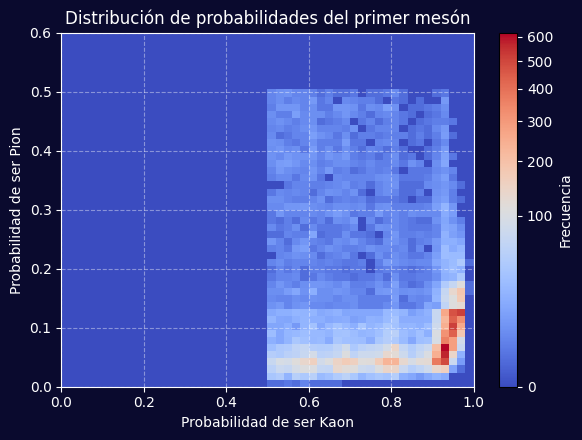

In [21]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_facecolor('#0a0a2e')

h, xedges, yedges, img = ax.hist2d(
    rd["H1_ProbK"],
    rd["H1_ProbPi"],
    bins=50,
    range=[[0, 1], [0, 0.6]],
    cmap="coolwarm",
    norm=mcolors.PowerNorm(gamma=0.4)
)
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("Frecuencia", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax.set_xlabel("Probabilidad de ser Kaon",  color="white")
ax.set_ylabel("Probabilidad de ser Pion", color="white")
ax.set_title("Distribución de probabilidades del primer mesón", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("white")
fig.patch.set_facecolor("#0a0a2e")
plt.tight_layout()
plt.savefig("graficas/Prob2D_50bins.png", dpi=1000, bbox_inches="tight")
plt.show()

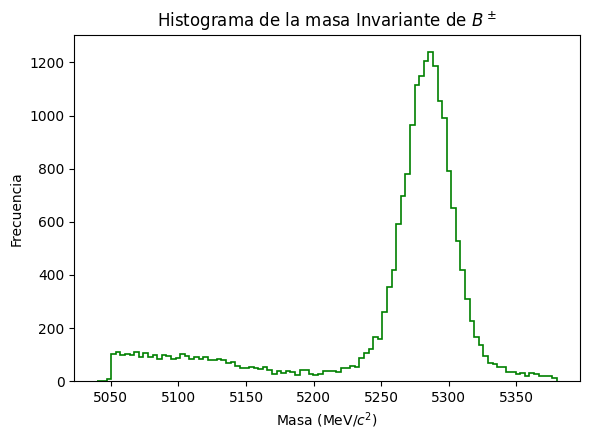

In [22]:
plt.rcParams.update({'axes.facecolor': 'white', 'axes.grid': False})

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(
    rd["B_M"],
    bins=100,
    range=(5040, 5380),
    histtype="step",
    color="green",
    linewidth=1.2
)
ax.set_xlabel(r"Masa (MeV/$c^2$)")
ax.set_ylabel("Frecuencia")
ax.set_title(r"Histograma de la masa Invariante de $B^\pm$")
plt.tight_layout()
plt.savefig("graficas/MInvariante_100bins.png", dpi=1000, bbox_inches="tight")
plt.show()

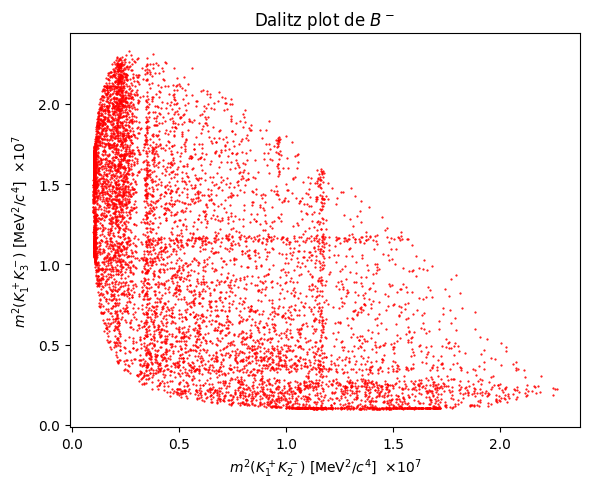

In [28]:
# Corte en ventana de masa y cálculo de masas de pares K+K-
df_sig = rd.query("(B_M > 5194) & (B_M < 5364)").copy()

df_sig["m2_12"] = (
    (df_sig["H1_E"]+df_sig["H2_E"])**2 - (df_sig["H1_PX"]+df_sig["H2_PX"])**2
    - (df_sig["H1_PY"]+df_sig["H2_PY"])**2 - (df_sig["H1_PZ"]+df_sig["H2_PZ"])**2
)

df_sig["m2_13"] = (
    (df_sig["H1_E"]+df_sig["H3_E"])**2 - (df_sig["H1_PX"]+df_sig["H3_PX"])**2
    - (df_sig["H1_PY"]+df_sig["H3_PY"])**2 - (df_sig["H1_PZ"]+df_sig["H3_PZ"])**2
)

# Solo B⁻ (carga total = -1)
df_Bm = df_sig.query("B_Charge == -1")

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor("white")
ax.scatter(
    df_Bm["m2_12"] / 1e1,
    df_Bm["m2_13"] / 1e1,
    s=0.3,
    color="red",
    alpha=1.0,
    rasterized=True
)
ax.set_xlabel(r"$m^2(K_1^+ K_2^-)\;[\mathrm{MeV}^2/c^4]$")
ax.set_ylabel(r"$m^2(K_1^+ K_3^-)\;[\mathrm{MeV}^2/c^4]$")
ax.set_title(r"Dalitz plot de $B^-$")
ax.xaxis.get_major_formatter().set_powerlimits((6, 6))
ax.yaxis.get_major_formatter().set_powerlimits((6, 6))
# Notación ×1e7
ax.xaxis.offsetText.set_visible(False)
ax.yaxis.offsetText.set_visible(False)
ax.set_xlabel(r"$m^2(K_1^+ K_2^-)\;[\mathrm{MeV}^2/c^4]$  $\times 10^7$")
ax.set_ylabel(r"$m^2(K_1^+ K_3^-)\;[\mathrm{MeV}^2/c^4]$  $\times 10^7$")
plt.tight_layout()
plt.savefig("graficas/Dalitz_Bm_scatter.png", dpi=1000, bbox_inches="tight")
plt.show()

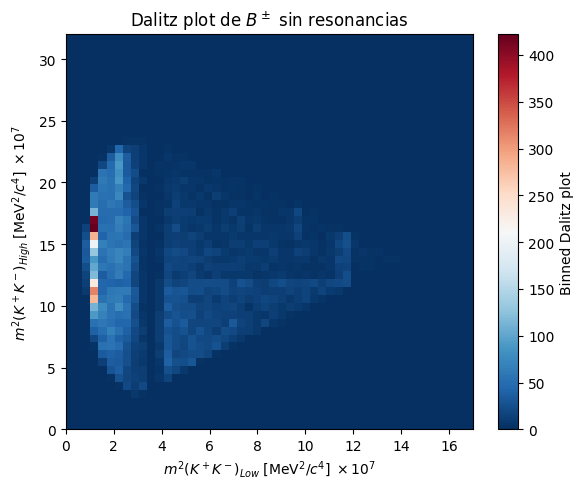

In [32]:
# Eliminar resonancias D0 (charm veto)
df_nocharm = df_sig.query(
    "((m2_12 < m2_13) & ((m2_12 < 1800**2) | (m2_12 > 2000**2))) | "
    "((m2_12 > m2_13) & ((m2_13 < 1800**2) | (m2_13 > 2000**2)))"
).copy()

R0low  = df_nocharm[["m2_12", "m2_13"]].min(axis=1)
R0high = df_nocharm[["m2_12", "m2_13"]].max(axis=1)

fig, ax = plt.subplots(figsize=(6, 5))
h2, xb, yb, img2 = ax.hist2d(
    R0low  / 1e6,
    R0high / 1e6,
    bins=50,
    range=[[0, 17], [0, 32]],
    cmap="Blues_r",
)
# Invertir mapa para que pocos eventos = oscuro
h2_plot, xb2, yb2, img2b = ax.hist2d(
    R0low  / 1e6,
    R0high / 1e6,
    bins=50,
    range=[[0, 17], [0, 32]],
    cmap="RdBu_r",
)
cbar2 = fig.colorbar(img2b, ax=ax)
cbar2.set_label("Binned Dalitz plot")
ax.set_xlabel(r"$m^2(K^+K^-)_{Low}\;[\mathrm{MeV}^2/c^4]\;\times 10^7$")
ax.set_ylabel(r"$m^2(K^+K^-)_{High}\;[\mathrm{MeV}^2/c^4]\;\times 10^7$")
ax.set_title(r"Dalitz plot de $B^\pm$ sin resonancias")
plt.tight_layout()
plt.savefig("graficas/Dalitz_sr.png", dpi=1000, bbox_inches="tight")
plt.show()

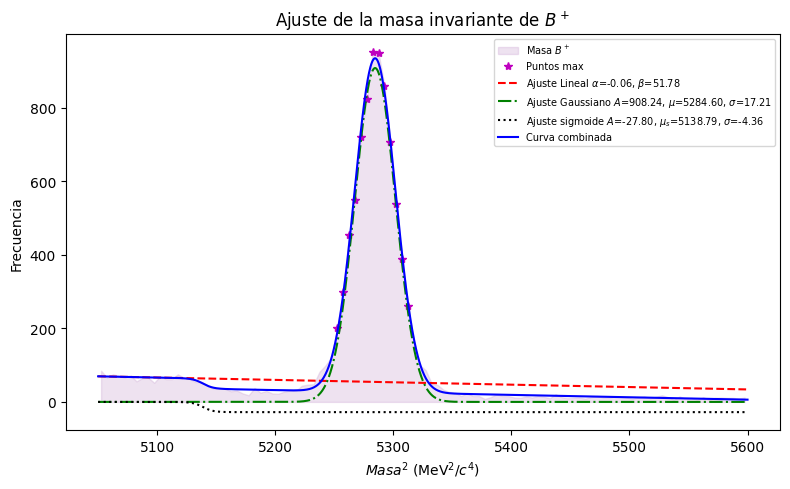

In [ ]:
MASS_MIN, MASS_MAX, N_BINS = 5050.0, 5600.0, 110
BIN_WIDTH  = (MASS_MAX - MASS_MIN) / N_BINS
MASS_CENTER = (MASS_MIN + MASS_MAX) / 2.0

masses_Bp = rd.loc[rd["B_Charge"] == 1, "B_M"].values
masses_Bp = masses_Bp[(masses_Bp >= MASS_MIN) & (masses_Bp <= MASS_MAX)]

counts, edges = np.histogram(masses_Bp, bins=N_BINS, range=(MASS_MIN, MASS_MAX))
centers = (edges[:-1] + edges[1:]) / 2.0
# Puntos de los máximos locales (bins por encima del 20% del máximo)
mask_max = counts > 0.2 * counts.max()

# ── Modelos ──
def gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def linear_bg(x, alpha, beta):
    return alpha * (x - MASS_CENTER) + beta

def sigmoid_bg(x, A, mu, sigma):
    return A / (1 + np.exp((x - mu) / sigma))

def combined(x, A_g, mu_g, sigma_g, alpha, beta, A_s, mu_s, sigma_s):
    return gauss(x, A_g, mu_g, sigma_g) + linear_bg(x, alpha, beta) + sigmoid_bg(x, A_s, mu_s, sigma_s)

p0 = [1000, 5280, 18, -0.05, 40, 30, 5170, -15]
try:
    popt, _ = cf(combined, centers, counts, p0=p0, maxfev=50000)
except Exception:
    popt = p0

x_dense = np.linspace(MASS_MIN, MASS_MAX, 2000)
A_g, mu_g, sg, al, be, A_s, mu_s, ss = popt

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor("white")
ax.fill_between(centers, counts, alpha=0.3, color="#c8a0d0", label=r"Masa $B^+$")
ax.plot(centers[mask_max], counts[mask_max], "m*", ms=6, label="Puntos max")
ax.plot(x_dense, linear_bg(x_dense, al, be), "r--", label=rf"Ajuste Lineal $\alpha$={al:.2f}, $\beta$={be:.2f}")
ax.plot(x_dense, gauss(x_dense, A_g, mu_g, sg), "g-.", label=rf"Ajuste Gaussiano $A$={A_g:.2f}, $\mu$={mu_g:.2f}, $\sigma$={sg:.2f}")
ax.plot(x_dense, sigmoid_bg(x_dense, A_s, mu_s, ss), "k:", label=rf"Ajuste sigmoide $A$={A_s:.2f}, $\mu_s$={mu_s:.2f}, $\sigma$={ss:.2f}")
ax.plot(x_dense, combined(x_dense, *popt), "b-", lw=1.5, label="Curva combinada")

ax.set_xlabel(r"$Masa^2\;(\mathrm{MeV}^2/c^4)$", style="italic")
ax.set_ylabel("Frecuencia")
ax.set_title(r"Ajuste de la masa invariante de $B^+$")
ax.legend(fontsize=7, framealpha=0.8)
plt.tight_layout()
plt.savefig("graficas/Ajuste_masa_Bp.png", dpi=1000, bbox_inches="tight")
plt.show()

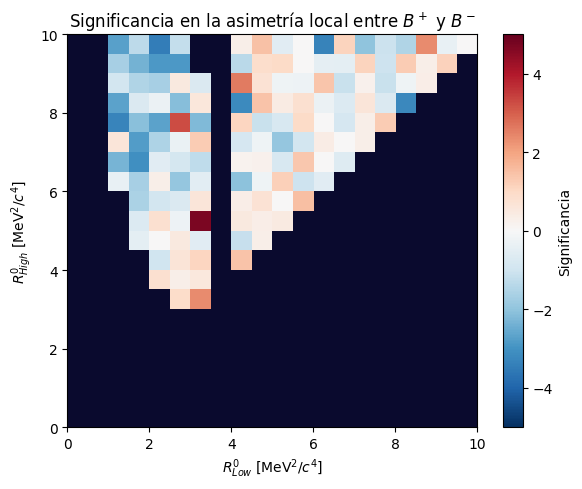

In [42]:
df_nocharm2 = df_nocharm.copy()
R0low2  = df_nocharm2[["m2_12", "m2_13"]].min(axis=1)
R0high2 = df_nocharm2[["m2_12", "m2_13"]].max(axis=1)

# Rangos en unidades 10^6 MeV²/c⁴ (≈ GeV²/c⁴)
BINS    = 20
X_RANGE = [0, 10e6]
Y_RANGE = [0, 10e6]

df_nocharm2["R0low"]  = R0low2.values
df_nocharm2["R0high"] = R0high2.values

Bp = df_nocharm2[df_nocharm2["B_Charge"] ==  1]
Bm = df_nocharm2[df_nocharm2["B_Charge"] == -1]

hBp, xb, yb = np.histogram2d(Bp["R0low"], Bp["R0high"], bins=BINS, range=[X_RANGE, Y_RANGE])
hBm, _,  _  = np.histogram2d(Bm["R0low"], Bm["R0high"], bins=BINS, range=[X_RANGE, Y_RANGE])

with np.errstate(divide="ignore", invalid="ignore"):
    A         = np.where(hBm + hBp > 0, (hBm - hBp) / (hBm + hBp), np.nan)
    sigma_A   = np.where(hBm + hBp > 0, np.sqrt((1 - A**2) / (hBm + hBp)), np.nan)
    signif    = np.where(sigma_A > 0, A / sigma_A, np.nan)

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor("#0a0a2e")
xc = (xb[:-1] + xb[1:]) / 2 / 1e6
yc = (yb[:-1] + yb[1:]) / 2 / 1e6

im = ax.matshow(
    signif.T,
    extent=[xb[0]/1e6, xb[-1]/1e6, yb[0]/1e6, yb[-1]/1e6],
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    vmin=-5, vmax=5
)
cbar3 = fig.colorbar(im, ax=ax)
cbar3.set_label("Significancia")
ax.xaxis.set_ticks_position("bottom")
ax.set_xlabel(r"$R^0_{Low}\;[\mathrm{MeV}^2/c^4]$")
ax.set_ylabel(r"$R^0_{High}\;[\mathrm{MeV}^2/c^4]$")
ax.set_title(r"Significancia en la asimetría local entre $B^+$ y $B^-$")
plt.tight_layout()
plt.savefig("graficas/Significancia_local.png", dpi=1000, bbox_inches="tight")
plt.show()